In [2]:
from pathlib import Path
import re
import pandas as pd

DATA_ROOT = Path('/home/ac.zzheng/power/GPGPU/coSched/data')
SYSTEMS = ['V100', 'A100', 'H100']
SECTION_RE = re.compile(r'^===== .*?/([^/ ]+) =====$')

def parse_perf_metrics(metrics_path: Path):
    rows = []
    current_app = None
    for raw_line in metrics_path.read_text().splitlines():
        line = raw_line.strip()
        if not line:
            continue
        match = SECTION_RE.match(line)
        if match:
            current_app = match.group(1)
            continue
        if current_app is None or line.startswith('cap=') or line.startswith('gpu_count'):
            continue
        parts = line.split()
        if len(parts) < 6:
            continue
        rows.append({
            'app': current_app,
            'gpu_count': int(parts[0]),
            'runtime_s': float(parts[1]),
            'avg_power_w': float(parts[2]),
        })
    return pd.DataFrame(rows)

all_dfs = {}
for system in SYSTEMS:
    sdf = parse_perf_metrics(DATA_ROOT / system / 'perf_metrics.txt')
    sdf = sdf[sdf.groupby('app')['gpu_count'].transform('nunique') == 4].copy()
    sdf = sdf.sort_values(['app', 'gpu_count']).reset_index(drop=True)
    all_dfs[system] = sdf

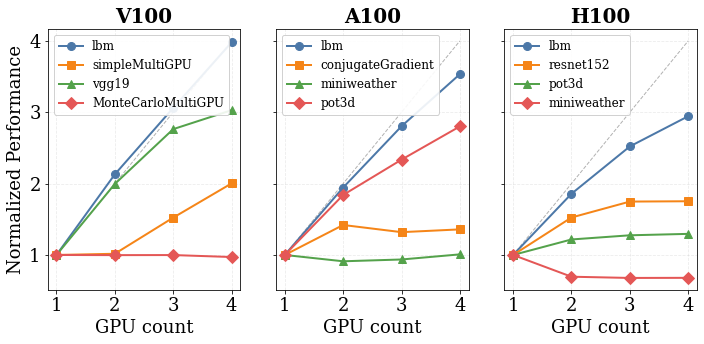

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
})

gpu_counts = [1, 2, 3, 4]
colors_pool = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#B07AA1']
markers_pool = ['o', 's', '^', 'D', 'v']

# Display names for legend (shorten long names)
legend_names = {
    'conjugateGradientMultiDeviceCG': 'conjugateGradient',
}

# Per-system app selections showing diverse scaling behaviors
system_apps = {
    'V100': [
        'lbm',                   # near-ideal ~4x
        'simpleMultiGPU',        # slow start, then scales ~2x
        'vgg19',                 # non-monotonic, best at 3 GPUs
        'MonteCarloMultiGPU',    # flat ~1x
    ],
    'A100': [
        'lbm',                   # strong ~3.5x
        'conjugateGradientMultiDeviceCG',             # non-monotonic, best at 2 GPUs
        'miniweather',           # flat/noisy ~1x
        'pot3d',                 # flat ~1x
    ],
    'H100': [
        'lbm',                   # best at 4 GPUs, decent scaling
        'resnet152',             # best at 4 but 3~=4, diminishing returns
        'pot3d',                 # nearly flat
        'miniweather',           # pathological / non-monotonic
    ],
}

fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharey=True)

for ax, system in zip(axes, SYSTEMS):
    sdf = all_dfs[system]
    base = sdf[sdf['gpu_count'] == 1][['app', 'runtime_s']].rename(columns={'runtime_s': 'base_runtime'})
    merged = sdf.merge(base, on='app')
    merged['speedup'] = merged['base_runtime'] / merged['runtime_s']

    apps = system_apps[system]
    for i, app in enumerate(apps):
        app_data = merged[merged['app'] == app].sort_values('gpu_count')
        display_name = legend_names.get(app, app)
        ax.plot(app_data['gpu_count'], app_data['speedup'],
                marker=markers_pool[i], color=colors_pool[i], linewidth=2, markersize=8,
                label=display_name, zorder=3)

    ax.plot(gpu_counts, gpu_counts, 'k--', alpha=0.3, linewidth=1)

    ax.set_xticks(gpu_counts)
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_xlabel('GPU count', fontsize=18)
    ax.set_title(system, fontsize=20, fontweight='bold')
    ax.legend(fontsize=12, loc='upper left', framealpha=0.9)
    ax.grid(axis='both', linestyle='--', alpha=0.25)
    ax.set_axisbelow(True)

axes[0].set_ylabel('Normalized Performance', fontsize=18)

# plt.suptitle('Performance Scaling Is Heterogeneous', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig('../fig/motivation_scaling.png', dpi=300, bbox_inches='tight')
plt.show()

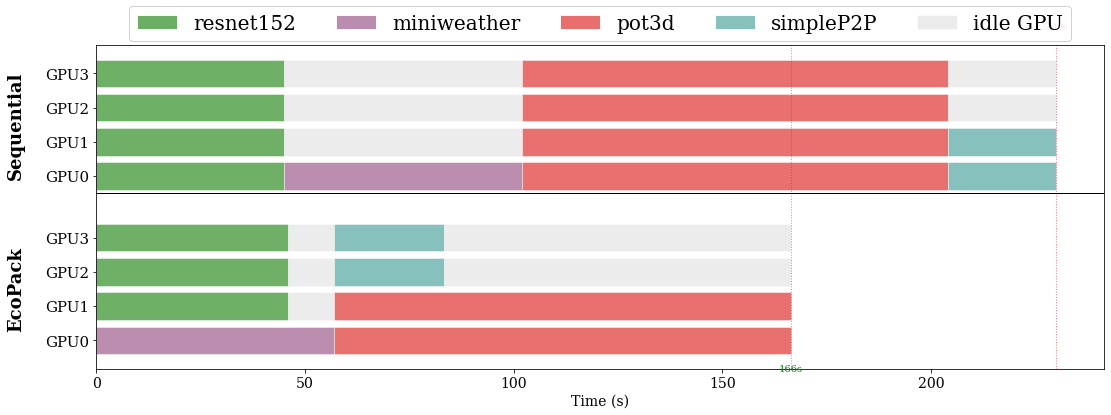

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
})

# H100 runtimes:
#   resnet152:   4 GPU = 45.87s,  3 GPU = 45.99s
#   miniweather: 4 GPU = 83.89s,  1 GPU = 57.01s (best at 1!)
#   pot3d:       4 GPU = 102.72s, 2 GPU = 109.34s (~6.4% slower)
#   simpleP2P:   2 GPU = 26.38s  (only 2-GPU config)

job_colors = {
    'resnet152':   '#54A24B',
    'miniweather': '#B07AA1',
    'pot3d':       '#E45756',
    'simpleP2P':   '#72B7B2',
}

def draw_job(ax, name, y_base, gpu_start, ngpu, t_start, runtime, color):
    for g in range(ngpu):
        ax.barh(y_base + gpu_start + g, runtime, left=t_start, height=0.8,
                color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
    # ax.text(t_start + runtime / 2, y_base + gpu_start + ngpu / 2 - 0.1, name,
    #         ha='center', va='center', fontsize=9, fontweight='bold', color='white')

def shade_idle(ax, y_base, gpu_start, ngpu, t_start, duration):
    for g in range(ngpu):
        ax.barh(y_base + gpu_start + g, duration, left=t_start, height=0.8,
                color='#E0E0E0', edgecolor='white', linewidth=0.5, alpha=0.6)

# ======================== Figure 2: Scheduling ========================
fig, ax = plt.subplots(figsize=(16, 6))

# --- Sequential: all jobs use 4 GPUs, one at a time ---
seq_y = 4.8
seq_jobs = [
    ('resnet152',   4, 45),
    ('miniweather', 1, 57),
    ('pot3d',       4, 102),
    ('simpleP2P',   2, 26),   # only 2-GPU available
]
t = 0
for name, ngpu, rt in seq_jobs:
    draw_job(ax, name, seq_y, 0, ngpu, t, rt, job_colors[name])
    if ngpu < 4:
        shade_idle(ax, seq_y, ngpu, 4 - ngpu, t, rt)
    t += rt
seq_total = t

# --- EcoPack co-scheduled ---
# Slot 1: miniweather (1 GPU, 57.01s) + resnet152 (3 GPUs, 45.99s)
# Slot 2: pot3d (2 GPUs, 109.34s) + simpleP2P (2 GPUs, 26.38s)
co_y = 0

# Slot 1: starts at t=0
draw_job(ax, 'miniweather', co_y, 0, 1, 0, 57.01, job_colors['miniweather'])
draw_job(ax, 'resnet152',   co_y, 1, 3, 0, 45.99, job_colors['resnet152'])
shade_idle(ax, co_y, 1, 3, 45.99, 57.01 - 45.99)

# Slot 2: starts at t=57.01
slot2_start = 57.01
draw_job(ax, 'pot3d',     co_y, 0, 2, slot2_start, 109.34, job_colors['pot3d'])
draw_job(ax, 'simpleP2P', co_y, 2, 2, slot2_start, 26.38,  job_colors['simpleP2P'])
shade_idle(ax, co_y, 2, 2, slot2_start + 26.38, 109.34 - 26.38)

cosched_total = slot2_start + 109.34  # 166.35s

# Divider
ax.axhline(y=4.3, color='black', linewidth=1, linestyle='-')

# GPU labels on the left y-axis for both groups
gpu_ticks = [co_y + i for i in range(4)] + [seq_y + i for i in range(4)]
gpu_labels = ['GPU0', 'GPU1', 'GPU2', 'GPU3'] * 2
ax.set_yticks(gpu_ticks)
ax.set_yticklabels(gpu_labels, fontsize=15)

ax.set_xlabel('Time (s)', fontsize=14)
# ax.set_title('Sequential Execution Wastes Energy', fontsize=16, fontweight='bold')

# EcoPack / Sequential labels on the far left (rotated text annotations)
ax.annotate('EcoPack', xy=(0, co_y + 1.5), xycoords=('axes fraction', 'data'),
            xytext=(-80, 0), textcoords='offset points',
            fontsize=18, fontweight='bold', ha='center', va='center', rotation=90)
ax.annotate('Sequential', xy=(0, seq_y + 1.5), xycoords=('axes fraction', 'data'),
            xytext=(-80, 0), textcoords='offset points',
            fontsize=18, fontweight='bold', ha='center', va='center', rotation=90)

# Application legend at the top
app_patches = [Patch(facecolor=color, edgecolor='white', alpha=0.85, label=name)
               for name, color in job_colors.items()]
idle_patch = Patch(facecolor='#E0E0E0', edgecolor='white', alpha=0.6, label='idle GPU')
ax.legend(handles=app_patches + [idle_patch], fontsize=20, loc='upper center',
          ncol=5, bbox_to_anchor=(0.5, 1.15), framealpha=0.9)

# Mark total makespan
ax.axvline(x=seq_total, color='red', linewidth=1, linestyle=':', alpha=0.5)
ax.axvline(x=cosched_total, color='green', linewidth=1, linestyle=':', alpha=0.5)
ax.text(seq_total, 9.1, f'{seq_total:.0f}s', ha='center', fontsize=10, color='red')
ax.text(cosched_total, -0.9, f'{cosched_total:.0f}s', ha='center', fontsize=10, color='green')

ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig('../fig/motivation_scheduling.png', dpi=300, bbox_inches='tight')
plt.show()